In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [53]:
import warnings
warnings.filterwarnings("ignore")

In [54]:
data = {
    "Age":[28,45,35,50,30,42,26,48,38,55],
    "AnnualIncome":[6.5,12,8,15,7,10,5.5,14,9,16],
    "CreditScore":[720,680,750,640,710,660,730,650,700,620],
    "LoanAmount":[5,10,6,12,5,9,4,11,7,13],
    "LoanTerm":[5,10,7,15,5,10,4,12,8,15],
    "EmploymentType":[
        "Salaried",
        "Self-Employed",
        "Salaried",
        "Self-Employed",
        "Salaried",
        "Salaried",
        "Salaried",
        "Self-Employed",
        "Salaried",
        "Self-Employed"
    ],
    "Loan":[0,1,0,1,0,1,0,1,0,1]
}

df = pd.DataFrame(data)

print(df)

   Age  AnnualIncome  CreditScore  LoanAmount  LoanTerm EmploymentType  Loan
0   28           6.5          720           5         5       Salaried     0
1   45          12.0          680          10        10  Self-Employed     1
2   35           8.0          750           6         7       Salaried     0
3   50          15.0          640          12        15  Self-Employed     1
4   30           7.0          710           5         5       Salaried     0
5   42          10.0          660           9        10       Salaried     1
6   26           5.5          730           4         4       Salaried     0
7   48          14.0          650          11        12  Self-Employed     1
8   38           9.0          700           7         8       Salaried     0
9   55          16.0          620          13        15  Self-Employed     1


Encode EmployeementType


In [55]:
encoder = LabelEncoder()

df["EmploymentType"] = encoder.fit_transform(df["EmploymentType"])

print(df)

   Age  AnnualIncome  CreditScore  LoanAmount  LoanTerm  EmploymentType  Loan
0   28           6.5          720           5         5               0     0
1   45          12.0          680          10        10               1     1
2   35           8.0          750           6         7               0     0
3   50          15.0          640          12        15               1     1
4   30           7.0          710           5         5               0     0
5   42          10.0          660           9        10               0     1
6   26           5.5          730           4         4               0     0
7   48          14.0          650          11        12               1     1
8   38           9.0          700           7         8               0     0
9   55          16.0          620          13        15               1     1


In [56]:
X = df.drop("Loan", axis=1)

In [57]:
print(X)

   Age  AnnualIncome  CreditScore  LoanAmount  LoanTerm  EmploymentType
0   28           6.5          720           5         5               0
1   45          12.0          680          10        10               1
2   35           8.0          750           6         7               0
3   50          15.0          640          12        15               1
4   30           7.0          710           5         5               0
5   42          10.0          660           9        10               0
6   26           5.5          730           4         4               0
7   48          14.0          650          11        12               1
8   38           9.0          700           7         8               0
9   55          16.0          620          13        15               1


In [58]:
Y = df["Loan"]

In [59]:
print(Y)

0    0
1    1
2    0
3    1
4    0
5    1
6    0
7    1
8    0
9    1
Name: Loan, dtype: int64


Split DataSet

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
print(X_train.shape)
print(X_test.shape)

(8, 6)
(2, 6)


Scale the Data

In [62]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Create KNN model

In [63]:
knn = KNeighborsClassifier(n_neighbors=3)

Train Model

In [64]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

Prediction

In [65]:
y_pred = knn.predict(X_test)

print(y_pred)

[0 1]


Accuracy

In [66]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 1.0


Confusion Matrix

In [67]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1 0]
 [0 1]]


Classification Report

In [68]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



Predict New Customer

In [69]:
new_customer = [[40,11,670,9,10,1]]

Scale

In [70]:
new_customer = scaler.transform(new_customer)

Predict

In [71]:
prediction = knn.predict(new_customer)

print(prediction)

if prediction[0] == 0:
    print("Loan Default Prediction: No (Safe Customer)")
else:
    print("Loan Default Prediction: Yes (High Risk Customer)")


[1]
Loan Default Prediction: Yes (High Risk Customer)


One more predict new costomer


In [72]:
new_customer2 = [[32, 7.5, 740, 5, 5, 0]]

# Scale the data
new_customer2 = scaler.transform(new_customer2)

# Predict
print(prediction2)
prediction2 = knn.predict(new_customer2)
if prediction2[0] == 0:
    print("Loan Default Prediction: No (Safe Customer)")
else:
    print("Loan Default Prediction: Yes (High Risk Customer)")

[0]
Loan Default Prediction: No (Safe Customer)


Credit Score vs Loan Status Graph


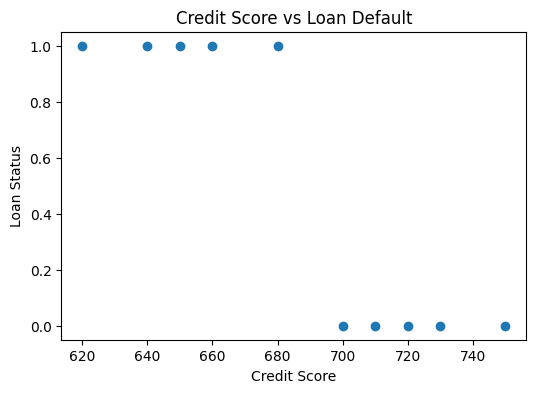

In [73]:
plt.figure(figsize=(6,4))

plt.scatter(df["CreditScore"], df["Loan"])

plt.xlabel("Credit Score")
plt.ylabel("Loan Status")
plt.title("Credit Score vs Loan Default")

plt.show()

nnual Income vs Loan Amount Graph

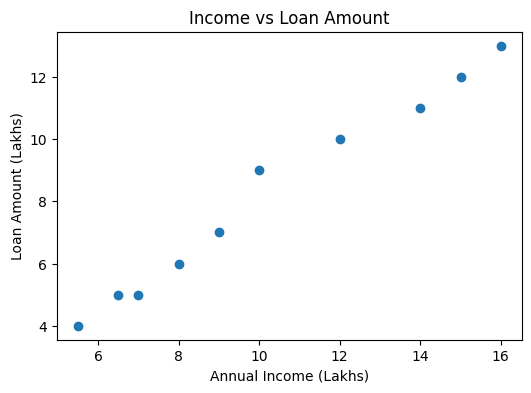

In [74]:
plt.figure(figsize=(6,4))

plt.scatter(df["AnnualIncome"], df["LoanAmount"])

plt.xlabel("Annual Income (Lakhs)")
plt.ylabel("Loan Amount (Lakhs)")
plt.title("Income vs Loan Amount")

plt.show()

Confusion Matrix (Model Performance)

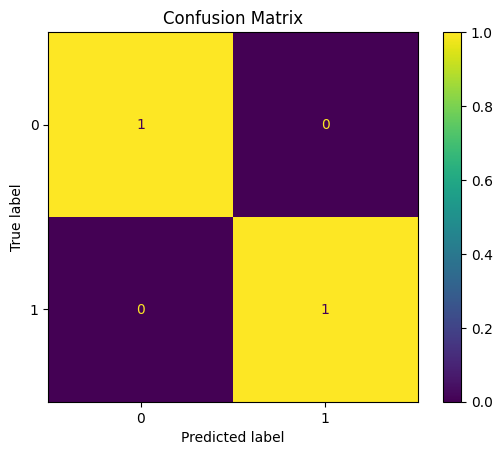

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)

plt.title("Confusion Matrix")

plt.show()

Accuracy Bar Chart

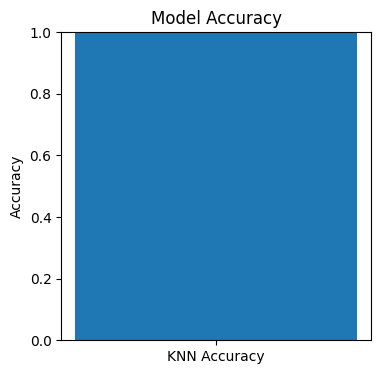

In [76]:
accuracy = accuracy_score(y_test, y_pred)

plt.figure(figsize=(4,4))

plt.bar(["KNN Accuracy"], [accuracy])

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Model Accuracy")

plt.show()